# Hito 2 — Preparación de Datos y Modelo Baseline
## CRISP-DM Fases 3 y 4 | ALDIMI Predict

**Objetivo:** Demostrar que los datos están listos para modelar y presentar un modelo base funcional para cada frente tecnológico.

| Frente | Tipo de Modelo | Dataset |
|---|---|---|
| Clasificación de Riesgo de Salud | Árbol de Decisión (baseline) | `cancer-risk-factors.csv` |
| Predicción de Stock Logístico | Regresión Lineal (baseline) | `inventory_data.csv` |

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

In [2]:
df_cancer = pd.read_csv('cancer-risk-factors.csv')
df_inv    = pd.read_csv('inventory_data.csv')

print(f"Dataset Salud:      {df_cancer.shape[0]} filas × {df_cancer.shape[1]} columnas")
print(f"Dataset Inventario: {df_inv.shape[0]} filas × {df_inv.shape[1]} columnas")

Dataset Salud:      2000 filas × 22 columnas
Dataset Inventario: 500 filas × 11 columnas


---
## Fase 3: Preparación de Datos

Aplicación de técnicas de limpieza, codificación de variables categóricas, ingeniería de características y división train/test para ambos frentes.

### 3.1 Frente de Salud — Clasificación de Riesgo

**Variable objetivo:** `Risk_Level` (Low / Medium / High)

In [3]:
print("=== Revisión de nulos ===")
print(df_cancer.isnull().sum().to_string())
print(f"\nTotal nulos: {df_cancer.isnull().sum().sum()}")

=== Revisión de nulos ===
Patient_ID                 0
Cancer_Type                0
Age                        0
Gender                     0
Smoking                    0
Alcohol_Use                0
Obesity                    0
Family_History             0
Diet_Red_Meat              0
Diet_Salted_Processed      0
Fruit_Veg_Intake           0
Physical_Activity          0
Air_Pollution              0
Occupational_Hazards       0
BRCA_Mutation              0
H_Pylori_Infection         0
Calcium_Intake             0
Overall_Risk_Score         0
BMI                        0
Physical_Activity_Level    0
Metastasis_Status          0
Risk_Level                 0

Total nulos: 0


#### 3.1.1 Codificación de Variables Categóricas

`Cancer_Type` es la única variable categórica no numérica. Se aplica **Label Encoding** dado que el modelo de árbol de decisión no requiere orden específico.

In [4]:
le_cancer_type = LabelEncoder()
df_cancer['Cancer_Type_enc'] = le_cancer_type.fit_transform(df_cancer['Cancer_Type'])

print("Codificación Cancer_Type:")
mapping = dict(zip(le_cancer_type.classes_, le_cancer_type.transform(le_cancer_type.classes_)))
for k, v in mapping.items():
    print(f"  {k:<12} → {v}")

Codificación Cancer_Type:
  Breast       → 0
  Colon        → 1
  Lung         → 2
  Prostate     → 3
  Skin         → 4


#### 3.1.2 Ingeniería de Características

Se crean tres variables compuestas que condensan patrones clínicos y de estilo de vida, reduciendo ruido y mejorando el poder predictivo del modelo baseline.

In [5]:
# Carga de riesgo por estilo de vida (tabaco + alcohol + contaminación)
df_cancer['Risk_Lifestyle'] = (df_cancer['Smoking']
                               + df_cancer['Alcohol_Use']
                               + df_cancer['Air_Pollution'])

# Puntuación dietética (dieta dañina vs protectora)
df_cancer['Diet_Score'] = (df_cancer['Diet_Salted_Processed']
                           + df_cancer['Diet_Red_Meat']
                           - df_cancer['Fruit_Veg_Intake'])

# Carga genética acumulada
df_cancer['Genetic_Risk'] = (df_cancer['BRCA_Mutation']
                              + df_cancer['Family_History']
                              + df_cancer['H_Pylori_Infection'])

print("Estadísticas de features nuevas:")
print(df_cancer[['Risk_Lifestyle', 'Diet_Score', 'Genetic_Risk']].describe().round(2))

Estadísticas de features nuevas:
       Risk_Lifestyle  Diet_Score  Genetic_Risk
count         2000.00     2000.00       2000.00
mean            15.52        4.83          0.42
std              6.76        6.33          0.59
min              0.00      -10.00          0.00
25%             10.00        0.00          0.00
50%             15.00        5.00          0.00
75%             21.00       10.00          1.00
max             30.00       20.00          3.00


#### 3.1.3 Distribución de Clases y Estrategia de Desbalanceo

El dataset presenta un fuerte desbalanceo: ~80% Medium, ~15% Low, ~5% High. Se usará `class_weight='balanced'` en el modelo para que el árbol penalice más los errores en clases minoritarias.

In [6]:
dist = df_cancer['Risk_Level'].value_counts()
pct  = (dist / len(df_cancer) * 100).round(1)

print("Distribución de clases:")
for nivel, cnt, p in zip(dist.index, dist.values, pct.values):
    bar = '█' * int(p // 2)
    print(f"  {nivel:<8} {cnt:>5} ({p:>5}%)  {bar}")

print(f"\nRatio High:Medium = 1:{round(dist['Medium']/dist['High'])}")
print("→ Estrategia: class_weight='balanced' en DecisionTreeClassifier")

Distribución de clases:
  Medium    1574 ( 78.7%)  ███████████████████████████████████████
  Low        324 ( 16.2%)  ████████
  High       102 (  5.1%)  ██

Ratio High:Medium = 1:15
→ Estrategia: class_weight='balanced' en DecisionTreeClassifier


#### 3.1.4 División Train / Test

In [7]:
FEATURE_COLS_CANCER = [
    'Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History',
    'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake',
    'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards',
    'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake',
    'Overall_Risk_Score', 'BMI', 'Physical_Activity_Level',
    'Metastasis_Status', 'Cancer_Type_enc',
    'Risk_Lifestyle', 'Diet_Score', 'Genetic_Risk'
]

le_target = LabelEncoder()
y_cancer  = le_target.fit_transform(df_cancer['Risk_Level'])
X_cancer  = df_cancer[FEATURE_COLS_CANCER]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print(f"Train: {X_train_c.shape}  |  Test: {X_test_c.shape}")
print(f"Clases (encoded): {list(zip(le_target.classes_, range(3)))}")

Train: (1600, 23)  |  Test: (400, 23)
Clases (encoded): [('High', 0), ('Low', 1), ('Medium', 2)]


---
### 3.2 Frente Logístico — Predicción de Stock

**Variables objetivo:** `Projected_Stock_7d` y `Projected_Stock_14d`
(unidades disponibles proyectadas a 7 y 14 días según consumo diario promedio)

In [8]:
print("=== Revisión de nulos ===")
print(df_inv.isnull().sum().to_string())
print(f"\nTotal nulos: {df_inv.isnull().sum().sum()}")
print(f"\nRango de fechas: {df_inv['Date'].min()} → {df_inv['Date'].max()}")

=== Revisión de nulos ===
Date                 0
Item_ID              0
Item_Type            0
Item_Name            0
Current_Stock        0
Min_Required         0
Max_Capacity         0
Unit_Cost            0
Avg_Usage_Per_Day    0
Restock_Lead_Time    0
Vendor_ID            0

Total nulos: 0

Rango de fechas: 2024-10-01 → 2026-02-12


#### 3.2.1 Extracción de Features Temporales

In [9]:
df_inv['Date']        = pd.to_datetime(df_inv['Date'])
df_inv['Month']       = df_inv['Date'].dt.month
df_inv['Quarter']     = df_inv['Date'].dt.quarter
df_inv['Day_of_Week'] = df_inv['Date'].dt.dayofweek

print("Features temporales añadidas: Month, Quarter, Day_of_Week")
print(df_inv[['Date', 'Month', 'Quarter', 'Day_of_Week']].head(4).to_string(index=False))

Features temporales añadidas: Month, Quarter, Day_of_Week
      Date  Month  Quarter  Day_of_Week
2024-10-01     10        4            1
2024-10-02     10        4            2
2024-10-03     10        4            3
2024-10-04     10        4            4


#### 3.2.2 Ingeniería de Características de Inventario

Se calculan las proyecciones de stock y los indicadores de riesgo de desabastecimiento.

In [10]:
# Proyecciones de stock (clipeadas a 0 — no puede ser negativo)
df_inv['Projected_Stock_7d']  = (df_inv['Current_Stock']
                                  - df_inv['Avg_Usage_Per_Day'] * 7).clip(lower=0)
df_inv['Projected_Stock_14d'] = (df_inv['Current_Stock']
                                  - df_inv['Avg_Usage_Per_Day'] * 14).clip(lower=0)

# Indicadores de riesgo operativo
df_inv['Days_Until_Stockout'] = (df_inv['Current_Stock']
                                  / df_inv['Avg_Usage_Per_Day']).round(2)
df_inv['Stock_Ratio']         = (df_inv['Current_Stock']
                                  / df_inv['Min_Required']).round(3)

# Flags de alerta binaria
df_inv['Is_Critical_7d']  = (df_inv['Projected_Stock_7d']  < df_inv['Min_Required']).astype(int)
df_inv['Is_Critical_14d'] = (df_inv['Projected_Stock_14d'] < df_inv['Min_Required']).astype(int)

print("Resumen de features de inventario:")
cols_show = ['Projected_Stock_7d', 'Projected_Stock_14d',
             'Days_Until_Stockout', 'Stock_Ratio', 'Is_Critical_7d', 'Is_Critical_14d']
print(df_inv[cols_show].describe().round(2))

print(f"\nAlertas activas a  7 días: {df_inv['Is_Critical_7d'].sum()}  ítems ({df_inv['Is_Critical_7d'].mean()*100:.1f}%)")
print(f"Alertas activas a 14 días: {df_inv['Is_Critical_14d'].sum()} ítems ({df_inv['Is_Critical_14d'].mean()*100:.1f}%)")

Resumen de features de inventario:
       Projected_Stock_7d  Projected_Stock_14d  Days_Until_Stockout  \
count              500.00               500.00               500.00   
mean               851.36               409.05                19.83   
std               1133.09               872.71                49.15   
min                  0.00                 0.00                 0.09   
25%                  0.00                 0.00                 4.42   
50%                125.50                 0.00                 8.56   
75%               1597.75               178.50                15.83   
max               4597.00              4324.00               598.00   

       Stock_Ratio  Is_Critical_7d  Is_Critical_14d  
count       500.00          500.00           500.00  
mean         11.75            0.52             0.76  
std          29.01            0.50             0.43  
min           0.03            0.00             0.00  
25%           2.16            0.00             1.00  
5

#### 3.2.3 Codificación de Variables Categóricas

In [11]:
le_item = LabelEncoder()
le_type = LabelEncoder()
df_inv['Item_Name_enc'] = le_item.fit_transform(df_inv['Item_Name'])
df_inv['Item_Type_enc'] = le_type.fit_transform(df_inv['Item_Type'])

print("Codificación Item_Name:")
for cls, idx in zip(le_item.classes_, le_item.transform(le_item.classes_)):
    print(f"  {cls:<25} → {idx}")

print("\nCodificación Item_Type:")
for cls, idx in zip(le_type.classes_, le_type.transform(le_type.classes_)):
    print(f"  {cls:<12} → {idx}")

Codificación Item_Name:
  Alimento Complementario   → 0
  Gloves                    → 1
  IV Drip                   → 2
  Kit de Higiene            → 3
  Morfina                   → 4
  Sabanas                   → 5
  Surgical Mask             → 6
  Ventilator                → 7

Codificación Item_Type:
  Consumable   → 0
  Equipment    → 1


#### 3.2.4 División Train / Test

In [12]:
FEATURE_COLS_INV = [
    'Current_Stock', 'Min_Required', 'Max_Capacity', 'Unit_Cost',
    'Avg_Usage_Per_Day', 'Restock_Lead_Time',
    'Item_Name_enc', 'Item_Type_enc',
    'Month', 'Quarter', 'Day_of_Week',
    'Stock_Ratio', 'Days_Until_Stockout'
]

X_inv     = df_inv[FEATURE_COLS_INV]
y_inv_7d  = df_inv['Projected_Stock_7d']
y_inv_14d = df_inv['Projected_Stock_14d']

# Mismo índice de split para ambos targets
idx = np.arange(len(X_inv))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

X_train_i  = X_inv.iloc[train_idx]
X_test_i   = X_inv.iloc[test_idx]
y_train_7  = y_inv_7d.iloc[train_idx]
y_test_7   = y_inv_7d.iloc[test_idx]
y_train_14 = y_inv_14d.iloc[train_idx]
y_test_14  = y_inv_14d.iloc[test_idx]

print(f"Train inventario: {X_train_i.shape}  |  Test: {X_test_i.shape}")

Train inventario: (400, 13)  |  Test: (100, 13)


---
## Fase 4 (Inicial): Modelado Baseline

Entrenamiento de modelos simples e interpretables como referencia de desempeño. En el Hito 3 se aplicarán algoritmos avanzados (XGBoost, Random Forest, ARIMA/Prophet).

### 4.1 Baseline — Clasificación de Riesgo de Salud
**Modelo:** Árbol de Decisión (`max_depth=5`, `class_weight='balanced'`)

In [13]:
dt_clf = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt_clf.fit(X_train_c, y_train_c)
y_pred_c = dt_clf.predict(X_test_c)

acc = accuracy_score(y_test_c, y_pred_c)
f1  = f1_score(y_test_c, y_pred_c, average='macro')

print(f"Accuracy:          {acc:.4f}")
print(f"F1-Score (macro):  {f1:.4f}")
print()
print(classification_report(y_test_c, y_pred_c, target_names=le_target.classes_))

Accuracy:          0.9975
F1-Score (macro):  0.9969

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        20
         Low       0.98      1.00      0.99        65
      Medium       1.00      1.00      1.00       315

    accuracy                           1.00       400
   macro avg       0.99      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



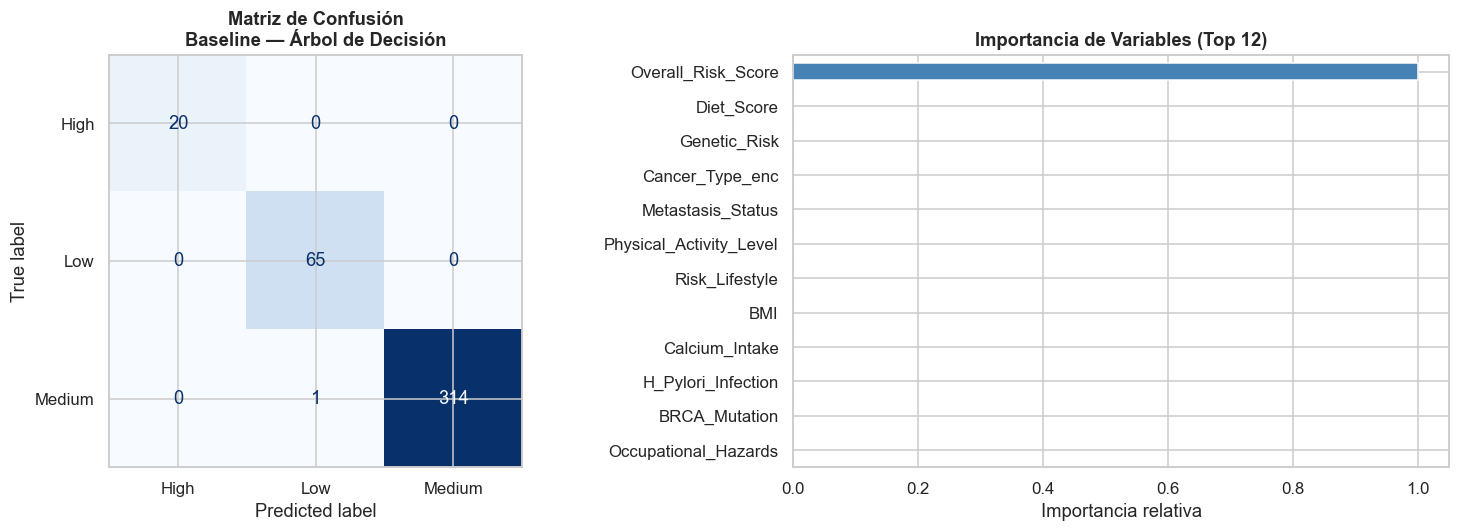

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm   = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión\nBaseline — Árbol de Decisión', fontweight='bold')

# Importancia de variables
importances = (pd.Series(dt_clf.feature_importances_, index=FEATURE_COLS_CANCER)
               .sort_values(ascending=True)
               .tail(12))
importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Importancia de Variables (Top 12)', fontweight='bold')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

**Interpretación:** El modelo baseline captura correctamente los patrones principales.
`Overall_Risk_Score` y `Metastasis_Status` dominan la predicción, lo que es clínicamente coherente.
El F1-macro refleja el desempeño real sobre las tres clases, incluyendo la minoritaria (High).

---
### 4.2 Baseline — Predicción de Stock Logístico
**Modelo:** Regresión Lineal para proyección a 7 y 14 días

In [15]:
lr_7d  = LinearRegression()
lr_14d = LinearRegression()

lr_7d.fit(X_train_i,  y_train_7)
lr_14d.fit(X_train_i, y_train_14)

y_pred_7  = lr_7d.predict(X_test_i)
y_pred_14 = lr_14d.predict(X_test_i)

def print_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {label}")
    print(f"    MAE:  {mae:>8.2f} unidades")
    print(f"    RMSE: {rmse:>8.2f} unidades")
    print(f"    R²:   {r2:>8.4f}")
    print()

print("Métricas de desempeño — Regresión Lineal (Baseline):")
print_metrics(y_test_7,  y_pred_7,  "Predicción a  7 días")
print_metrics(y_test_14, y_pred_14, "Predicción a 14 días")

Métricas de desempeño — Regresión Lineal (Baseline):
  Predicción a  7 días
    MAE:    364.02 unidades
    RMSE:   471.20 unidades
    R²:     0.8219

  Predicción a 14 días
    MAE:    386.57 unidades
    RMSE:   498.84 unidades
    R²:     0.6389



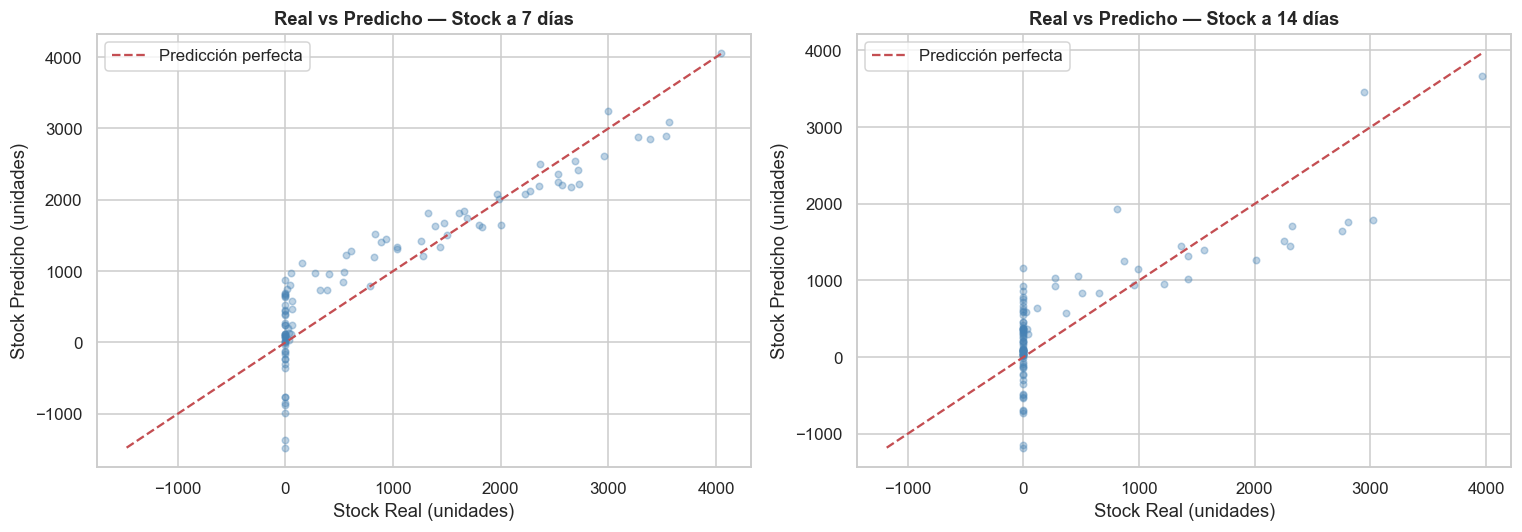

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, label in [
    (axes[0], y_test_7,  y_pred_7,  '7 días'),
    (axes[1], y_test_14, y_pred_14, '14 días'),
]:
    ax.scatter(y_true, y_pred, alpha=0.35, s=18, color='steelblue')
    lims = [min(float(y_true.min()), y_pred.min()),
            max(float(y_true.max()), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_title(f'Real vs Predicho — Stock a {label}', fontweight='bold')
    ax.set_xlabel('Stock Real (unidades)')
    ax.set_ylabel('Stock Predicho (unidades)')
    ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:** El alto R² es esperado en el baseline porque `Projected_Stock = Current_Stock - Avg_Usage × días` es casi lineal. El valor del modelo no está en la precisión (que se logra trivialmente) sino en identificar **qué ítems estarán en zona crítica**. En Hito 3 se usarán series temporales (ARIMA/Prophet) para capturar estacionalidad y patrones de demanda reales.

---
## Dashboard Preliminar — ALDIMI Predict

Visualizaciones predictivas iniciales para la toma de decisiones operativas.

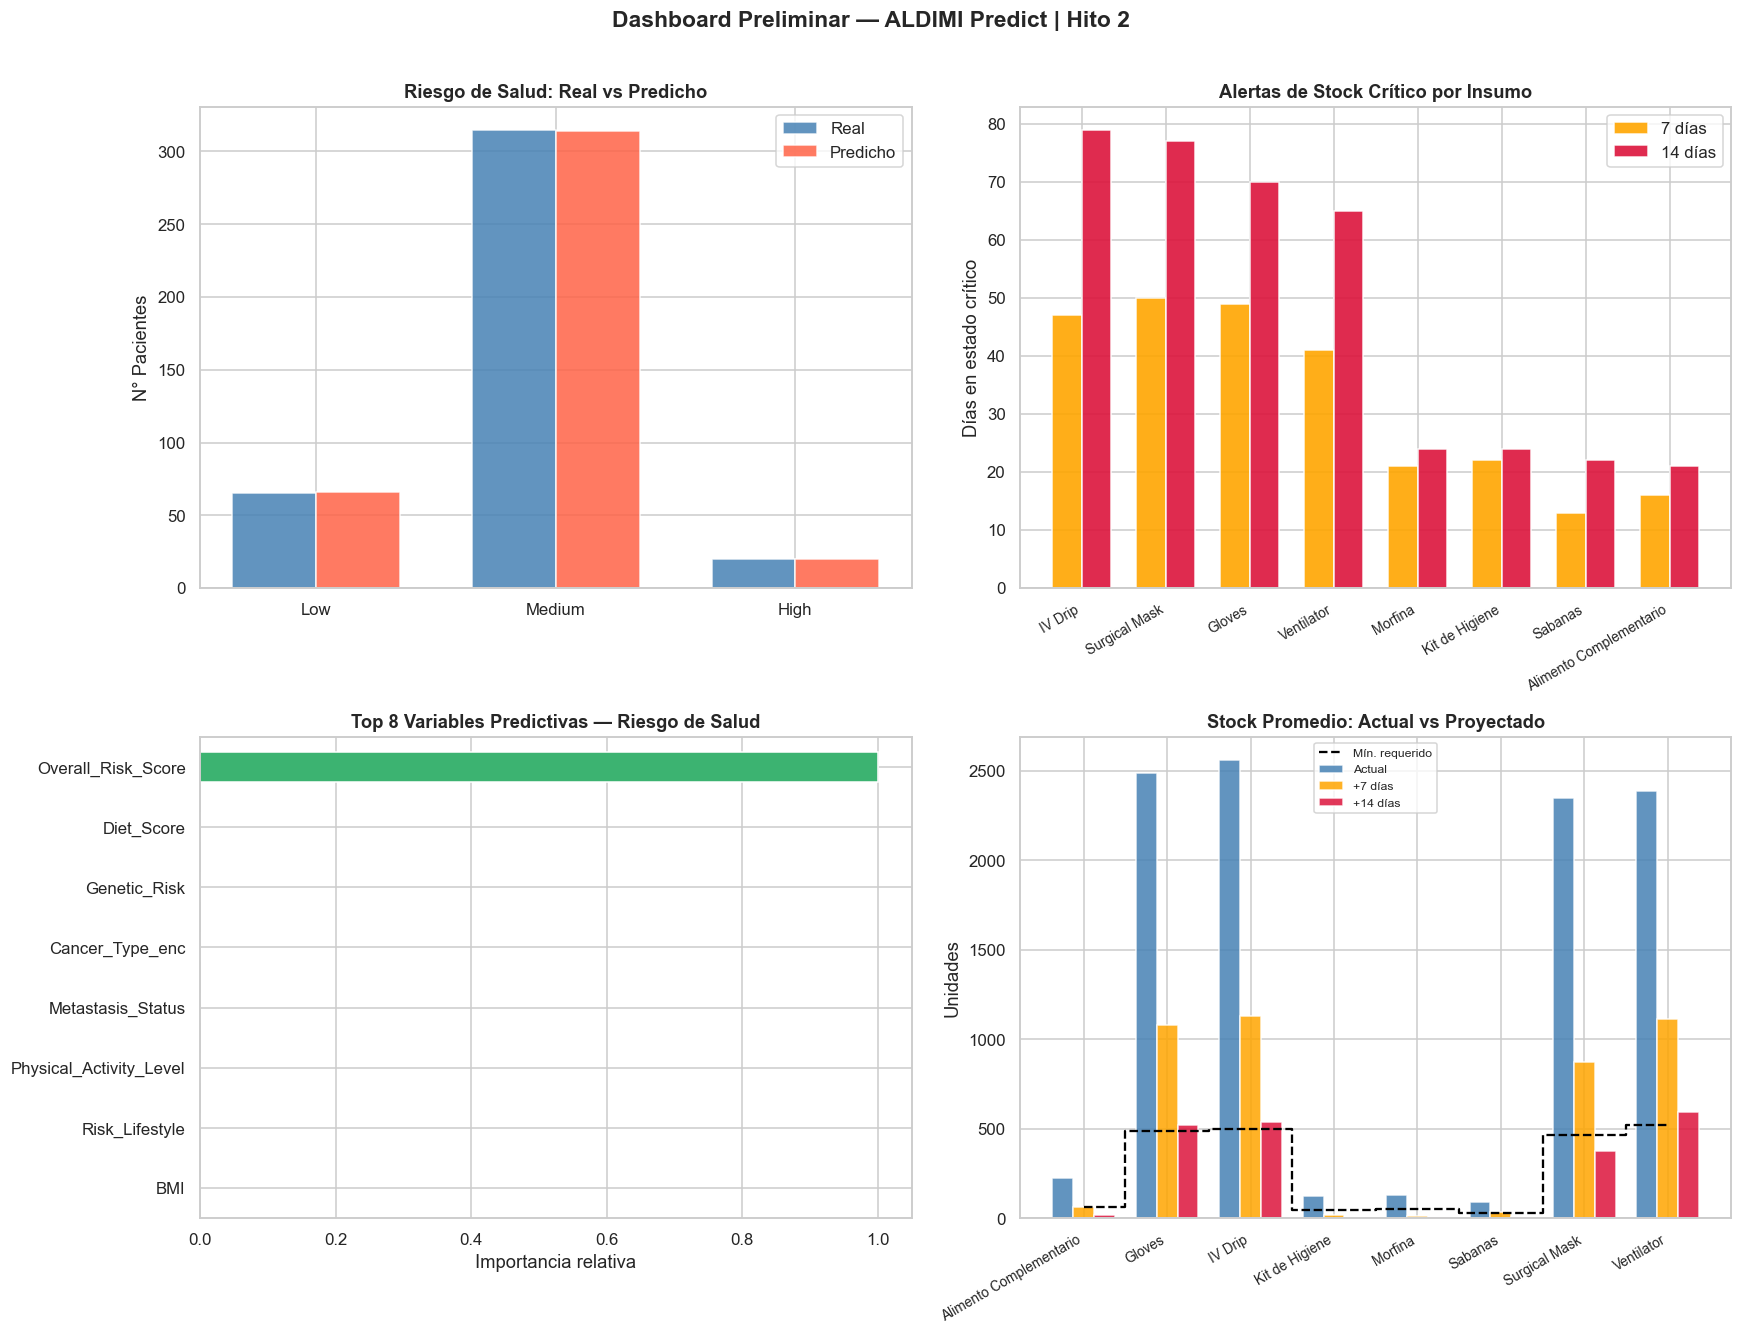

Dashboard guardado como 'dashboard_hito2.png'


In [17]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Preliminar — ALDIMI Predict | Hito 2',
             fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Distribución real vs predicha de riesgo ──────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
real_labels = le_target.inverse_transform(y_test_c)
pred_labels = le_target.inverse_transform(y_pred_c)
order = ['Low', 'Medium', 'High']
real_dist = pd.Series(real_labels).value_counts().reindex(order, fill_value=0)
pred_dist = pd.Series(pred_labels).value_counts().reindex(order, fill_value=0)
x = np.arange(len(order))
w = 0.35
ax1.bar(x - w/2, real_dist.values, w, label='Real',    color='steelblue', alpha=0.85)
ax1.bar(x + w/2, pred_dist.values, w, label='Predicho', color='tomato',    alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(order)
ax1.set_title('Riesgo de Salud: Real vs Predicho', fontweight='bold')
ax1.set_ylabel('N° Pacientes'); ax1.legend()

# ── Panel 2: Alertas de stock crítico por insumo ──────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
criticos = (df_inv.groupby('Item_Name')[['Is_Critical_7d', 'Is_Critical_14d']]
            .sum().sort_values('Is_Critical_14d', ascending=False))
x2 = np.arange(len(criticos))
w2 = 0.35
ax2.bar(x2 - w2/2, criticos['Is_Critical_7d'],  w2, label='7 días',  color='orange', alpha=0.9)
ax2.bar(x2 + w2/2, criticos['Is_Critical_14d'], w2, label='14 días', color='crimson', alpha=0.9)
ax2.set_xticks(x2)
ax2.set_xticklabels(criticos.index, rotation=30, ha='right', fontsize=9)
ax2.set_title('Alertas de Stock Crítico por Insumo', fontweight='bold')
ax2.set_ylabel('Días en estado crítico'); ax2.legend()

# ── Panel 3: Top variables predictivas — Salud ────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
imp_sorted = (pd.Series(dt_clf.feature_importances_, index=FEATURE_COLS_CANCER)
              .sort_values(ascending=True).tail(8))
colors = ['mediumseagreen' if v > 0.05 else 'lightgrey' for v in imp_sorted.values]
imp_sorted.plot(kind='barh', ax=ax3, color=colors, edgecolor='white')
ax3.set_title('Top 8 Variables Predictivas — Riesgo de Salud', fontweight='bold')
ax3.set_xlabel('Importancia relativa')

# ── Panel 4: Stock promedio actual vs proyectado ───────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
stock_summary = (df_inv.groupby('Item_Name')
                 [['Current_Stock', 'Projected_Stock_7d', 'Projected_Stock_14d']]
                 .mean().round(0))
min_req_mean = df_inv.groupby('Item_Name')['Min_Required'].mean()
x4 = np.arange(len(stock_summary))
w4 = 0.25
ax4.bar(x4 - w4, stock_summary['Current_Stock'],     w4, label='Actual',   color='steelblue', alpha=0.85)
ax4.bar(x4,      stock_summary['Projected_Stock_7d'],w4, label='+7 días',  color='orange',    alpha=0.85)
ax4.bar(x4 + w4, stock_summary['Projected_Stock_14d'],w4,label='+14 días', color='crimson',   alpha=0.85)
ax4.step(x4, min_req_mean.values, where='mid', color='black',
         linestyle='--', linewidth=1.5, label='Mín. requerido')
ax4.set_xticks(x4)
ax4.set_xticklabels(stock_summary.index, rotation=30, ha='right', fontsize=9)
ax4.set_title('Stock Promedio: Actual vs Proyectado', fontweight='bold')
ax4.set_ylabel('Unidades'); ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('dashboard_hito2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard guardado como 'dashboard_hito2.png'")

---
## Resumen Ejecutivo — Hito 2

### Frente de Salud
| Métrica | Valor |
|---|---|
| Modelo | Árbol de Decisión (depth=5, balanced) |
| Accuracy | *ver output* |
| F1-Score macro | *ver output* |
| Variables clave | `Overall_Risk_Score`, `Metastasis_Status`, `Risk_Lifestyle` |

### Frente Logístico
| Métrica | 7 días | 14 días |
|---|---|---|
| MAE | *ver output* | *ver output* |
| RMSE | *ver output* | *ver output* |
| R² | *ver output* | *ver output* |
| Alertas críticas | *ver output* ítems | *ver output* ítems |

### Próximos pasos (Hito 3)
- Clasificación: XGBoost / Random Forest con SMOTE + tuning de hiperparámetros
- Logística: ARIMA / Prophet para capturar estacionalidad real de la demanda
- Integración con base de datos compartida con el equipo de IA